In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [305]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/survey_results_public.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83439 entries, 0 to 83438
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ResponseId                    83439 non-null  int64  
 1   MainBranch                    83439 non-null  object 
 2   Employment                    83323 non-null  object 
 3   Country                       83439 non-null  object 
 4   US_State                      14920 non-null  object 
 5   UK_Country                    4418 non-null   object 
 6   EdLevel                       83126 non-null  object 
 7   Age1stCode                    83243 non-null  object 
 8   LearnCode                     82963 non-null  object 
 9   YearsCode                     81641 non-null  object 
 10  YearsCodePro                  61216 non-null  object 
 11  DevType                       66484 non-null  object 
 12  OrgSize                       60726 non-null  object 
 13  C

In [306]:
data.head()

,ResponseId,MainBranch,Employment,Country,US_State,UK_Country,EdLevel,Age1stCode,LearnCode,YearsCode,...,Age,Gender,Trans,Sexuality,Ethnicity,Accessibility,MentalHealth,SurveyLength,SurveyEase,ConvertedCompYearly
0,1,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Slovakia,NaN,NaN,"Secondary school (e.g. American high school, G...",18 - 24 years,Coding Bootcamp;Other online resources (ex: vi...,NaN,...,25-34 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,62268.0
1,2,I am a student who is learning to code,"Student, full-time",Netherlands,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",7,...,18-24 years old,Man,No,Straight / Heterosexual,White or of European descent,None of the above,None of the above,Appropriate in length,Easy,NaN
2,3,"I am not primarily a developer, but I write co...","Student, full-time",Russian Federation,NaN,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",11 - 17 years,"Other online resources (ex: videos, blogs, etc...",NaN,...,18-24 years old,Man,No,Prefer not to say,Prefer not to say,None of the above,None of the above,Appropriate in length,Easy,NaN
3,4,I am a developer by profession,Employed full-time,Austria,NaN,NaN,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",11 - 17 years,NaN,NaN,...,35-44 years old,Man,No,Straight / Heterosexual,White or of European descent,I am deaf / hard of hearing,NaN,Appropriate in length,Neither easy nor difficult,NaN
4,5,I am a developer by profession,"Independent contractor, freelancer, or self-em...",United Kingdom of Great Britain and Northern I...,NaN,England,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",5 - 10 years,Friend or family member,17,...,25-34 years old,Man,No,NaN,White or of European descent,None of the above,NaN,Appropriate in length,Easy,NaN


In [307]:
r_data = data[['Age','Country','LanguageHaveWorkedWith','LearnCode']]

In [308]:
r_data['Age']

,Age
0,25-34 years old
1,18-24 years old
2,18-24 years old
3,35-44 years old
4,25-34 years old
...,...
83434,25-34 years old
83435,18-24 years old
83436,25-34 years old
83437,25-34 years old


In [309]:
size_by_age=r_data.groupby(['Age']).size()
size_by_age

,0
Age,
18-24 years old,20993
25-34 years old,32568
35-44 years old,15183
45-54 years old,5472
55-64 years old,1819
65 years or older,421
Prefer not to say,575
Under 18 years old,5376


In [310]:
size_by_country=r_data.groupby(['Country']).size()
size_by_country

,0
Country,
Afghanistan,65
Albania,73
Algeria,46
Andorra,12
Angola,27
...,...
"Venezuela, Bolivarian Republic of...",104
Viet Nam,386
Yemen,20


<Axes: xlabel='Age'>

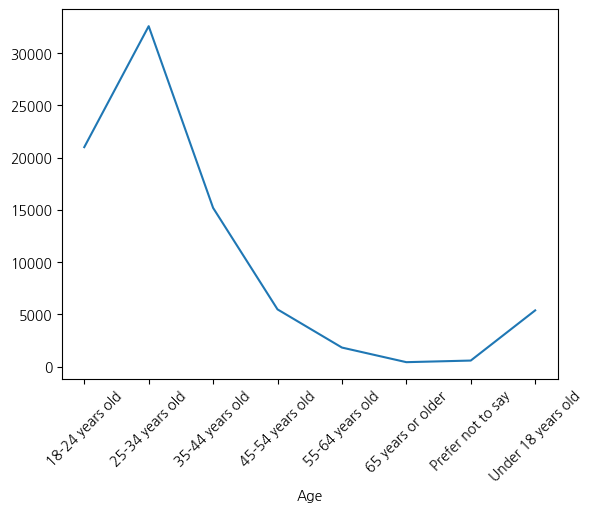

In [311]:
size_by_age.plot(rot=45)

<Axes: xlabel='Age'>

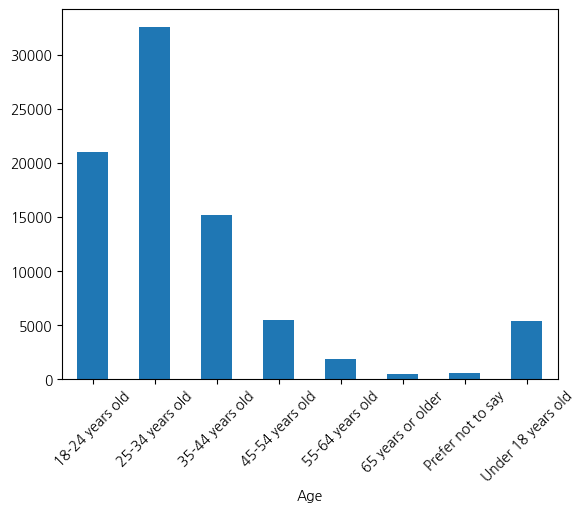

In [312]:
size_by_age.plot.bar(rot=45)

<Axes: ylabel='Age'>

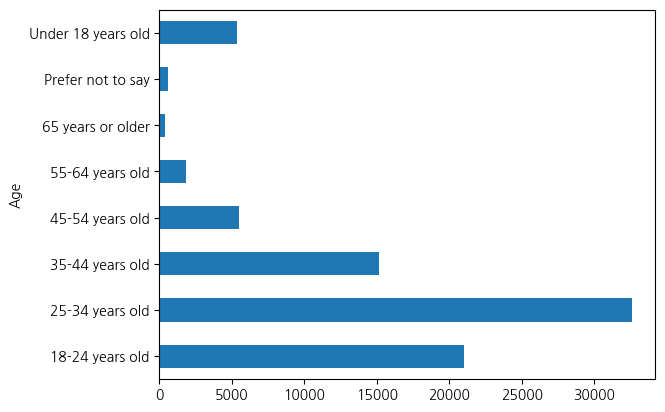

In [313]:
size_by_age.plot.barh()

In [314]:
size_by_age.index

Index(['18-24 years old', '25-34 years old', '35-44 years old',
       '45-54 years old', '55-64 years old', '65 years or older',
       'Prefer not to say', 'Under 18 years old'],
      dtype='object', name='Age')

In [315]:
reindex_size_by_age = size_by_age.reindex(index=[
    'Prefer not to say',
    '65 years or older',
    '55-64 years old',
    '45-54 years old',
    '35-44 years old',
    '25-34 years old',
    '18-24 years old',
    'Under 18 years old'
])
reindex_size_by_age

,0
Age,
Prefer not to say,575
65 years or older,421
55-64 years old,1819
45-54 years old,5472
35-44 years old,15183
25-34 years old,32568
18-24 years old,20993
Under 18 years old,5376


<Axes: ylabel='Age'>

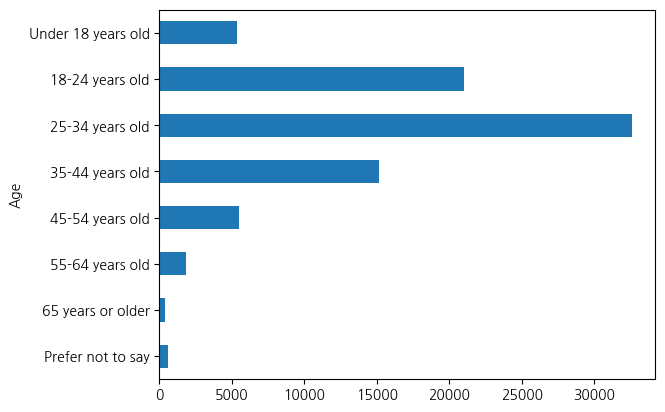

In [316]:
reindex_size_by_age.plot.barh()

<Axes: >

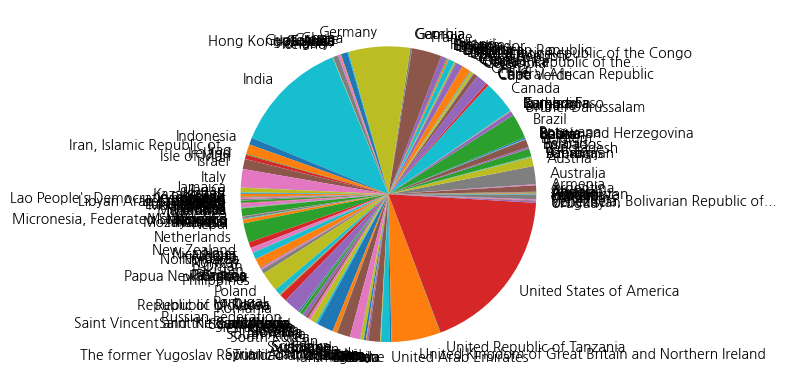

In [317]:
size_by_country.plot.pie()

<Axes: >

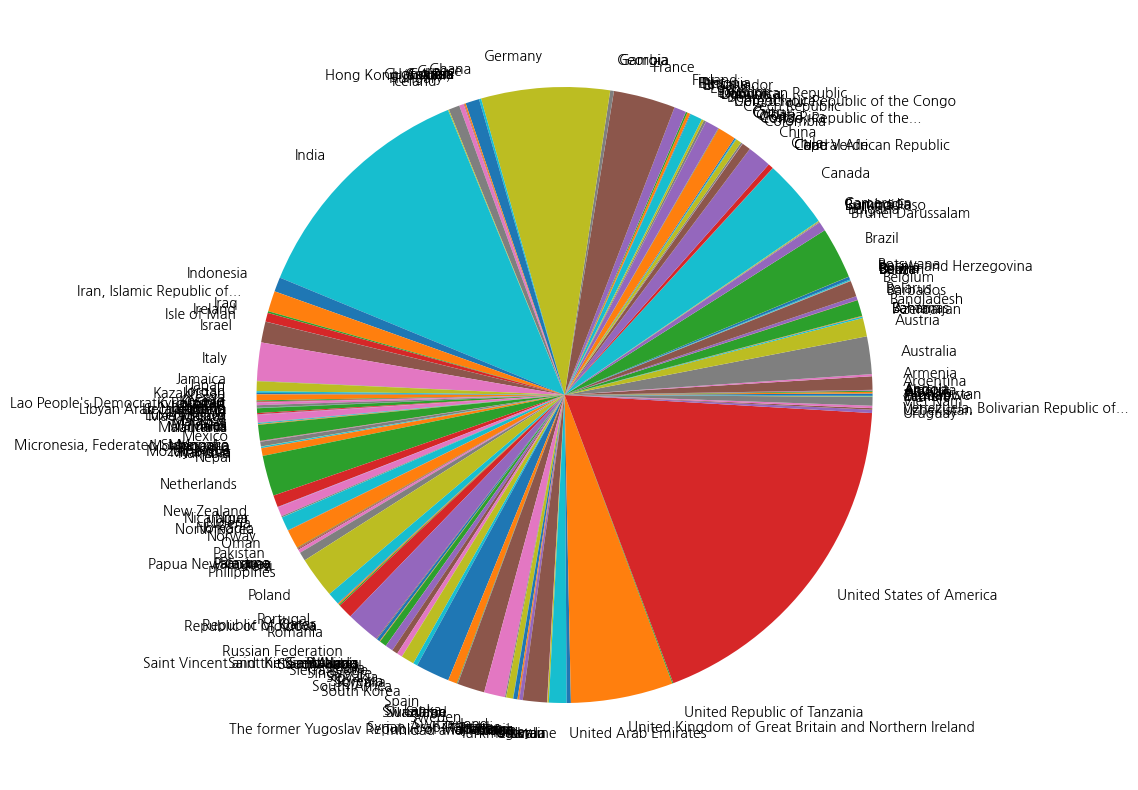

In [318]:
size_by_country.plot.pie(figsize=(10,10))

<Axes: >

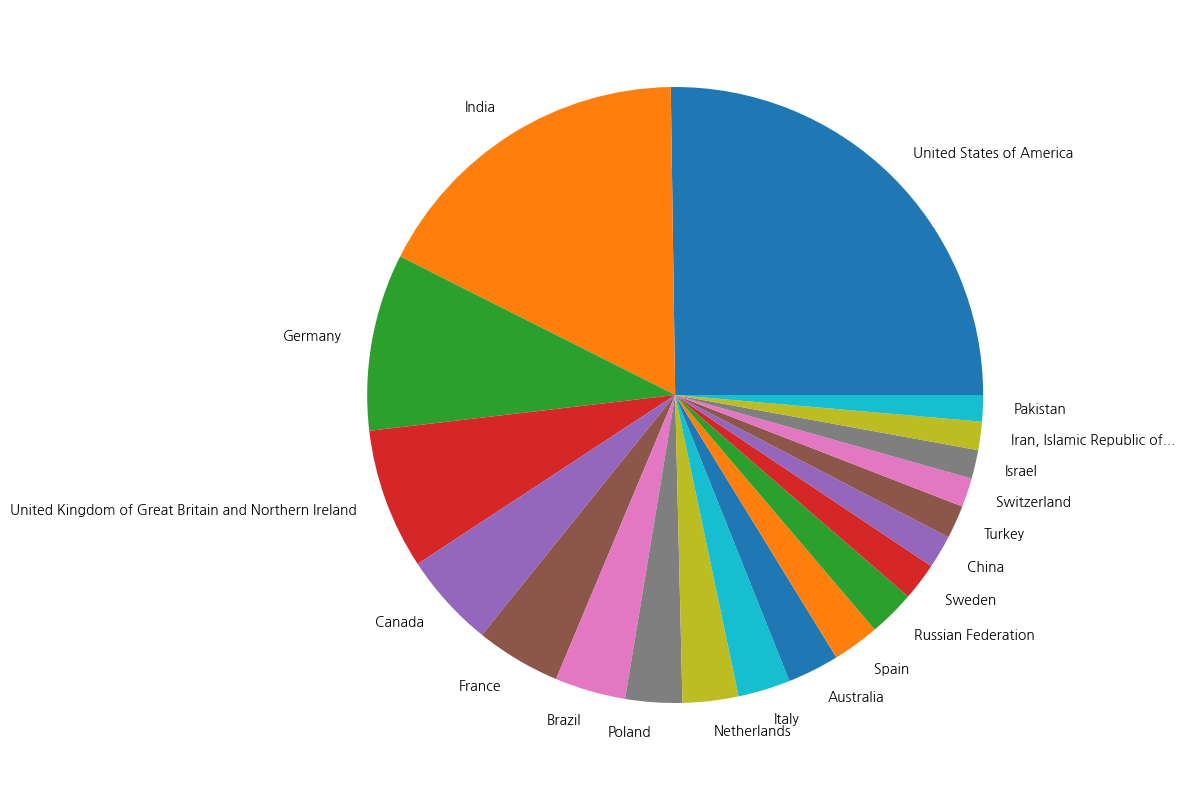

In [319]:
# 상위 N개의 데이터를 추출하는 nlargest()

size_by_country.nlargest(20).plot.pie(figsize=(10,10))

In [320]:
lang = r_data['LanguageHaveWorkedWith']

In [321]:
langs = lang.str.split(';')
langs

,LanguageHaveWorkedWith
0,"[C++, HTML/CSS, JavaScript, Objective-C, PHP, ..."
1,"[JavaScript, Python]"
2,"[Assembly, C, Python, R, Rust]"
3,"[JavaScript, TypeScript]"
4,"[Bash/Shell, HTML/CSS, Python, SQL]"
...,...
83434,"[Clojure, Kotlin, SQL]"
83435,NaN
83436,"[Groovy, Java, Python]"
83437,"[Bash/Shell, JavaScript, Node.js, Python]"


In [322]:
e_lang = langs.explode()
e_lang

,LanguageHaveWorkedWith
0,C++
0,HTML/CSS
0,JavaScript
0,Objective-C
0,PHP
...,...
83438,Delphi
83438,Elixir
83438,HTML/CSS
83438,Java


In [323]:
size_by_lang=e_lang.groupby(e_lang).size()

<Axes: ylabel='LanguageHaveWorkedWith'>

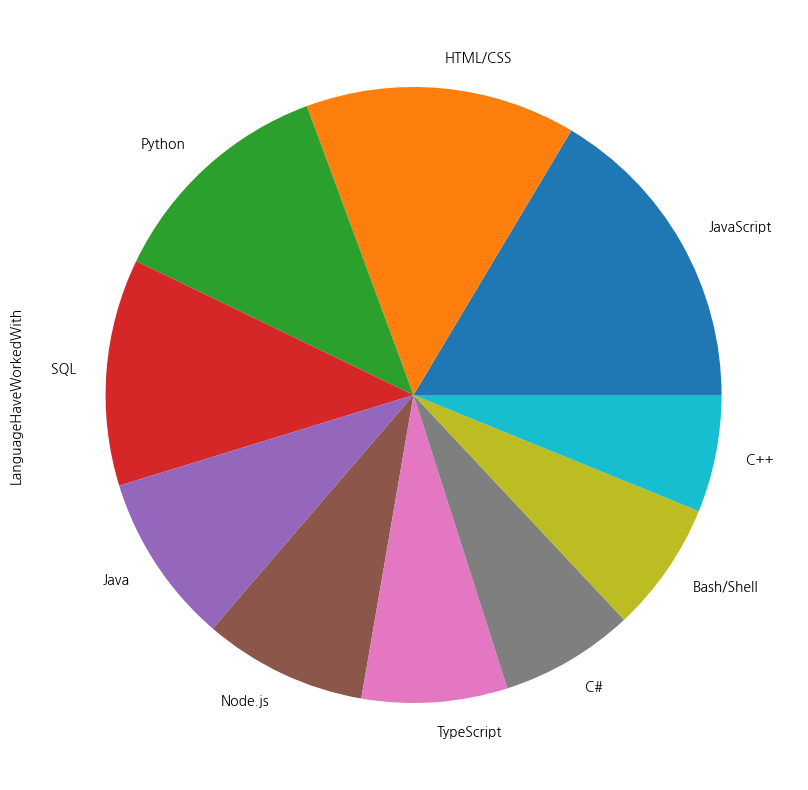

In [324]:
size_by_lang.nlargest(10).plot.pie(figsize=(10, 10))

<Axes: ylabel='LanguageHaveWorkedWith'>

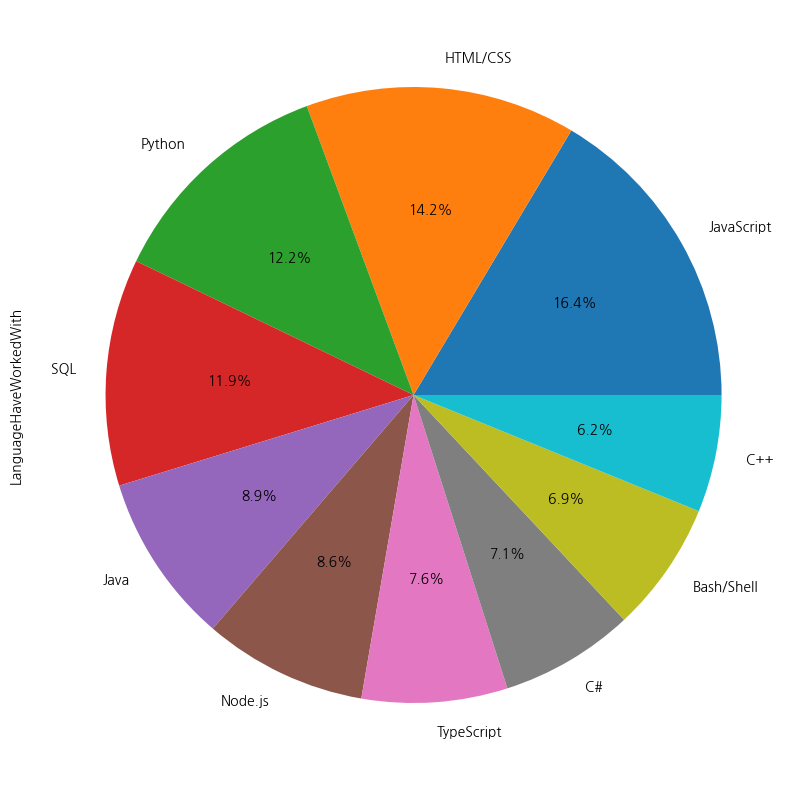

In [325]:
size_by_lang.nlargest(10).plot.pie(figsize=(10, 10), autopct='%1.1f%%')

In [326]:
# 25-34세 연령대의 개발자들이 사용한 프로그래킹 언어 중 상위 10개 추출 그래프
lang_25_34 = r_data[r_data.Age=='25-34 years old']['LanguageHaveWorkedWith'].str.split(';').explode()
lang_25_34

,LanguageHaveWorkedWith
0,C++
0,HTML/CSS
0,JavaScript
0,Objective-C
0,PHP
...,...
83436,Python
83437,Bash/Shell
83437,JavaScript
83437,Node.js


In [327]:
size_by_lang_25_34=lang_25_34.groupby(lang_25_34).size().nlargest(10)
size_by_lang_25_34

,LanguageHaveWorkedWith
LanguageHaveWorkedWith,
JavaScript,21403
HTML/CSS,17520
SQL,15468
Python,14140
TypeScript,11253
Node.js,11211
Java,10544
Bash/Shell,8512
C#,8370


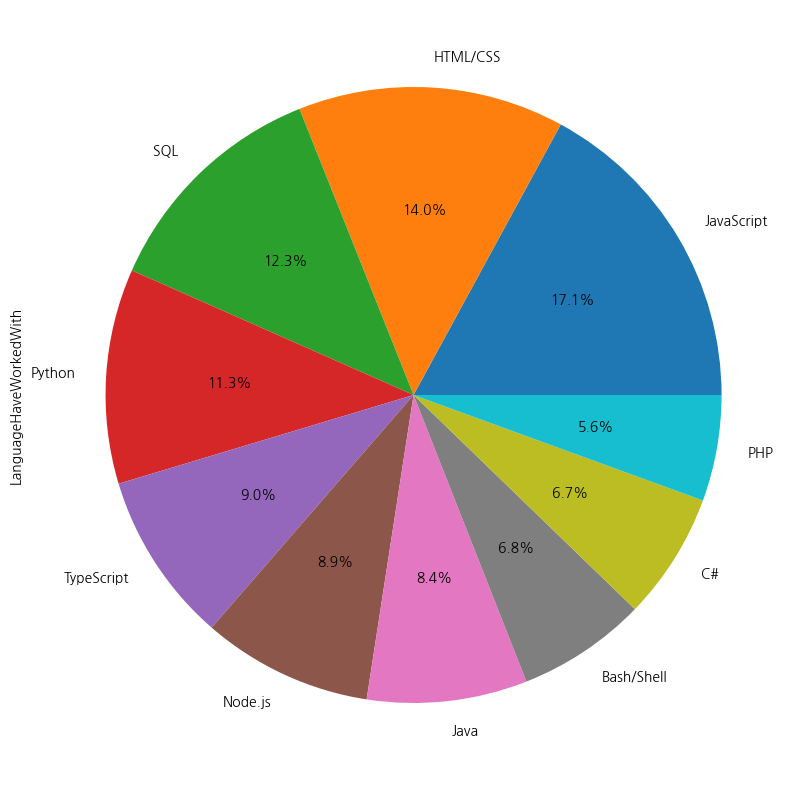

In [328]:
size_by_lang_25_34=lang_25_34.groupby(lang_25_34).size().nlargest(10).plot.pie(figsize=(10,10),autopct='%1.1f%%')

Text(0.5, 1.0, 'LearnCode')

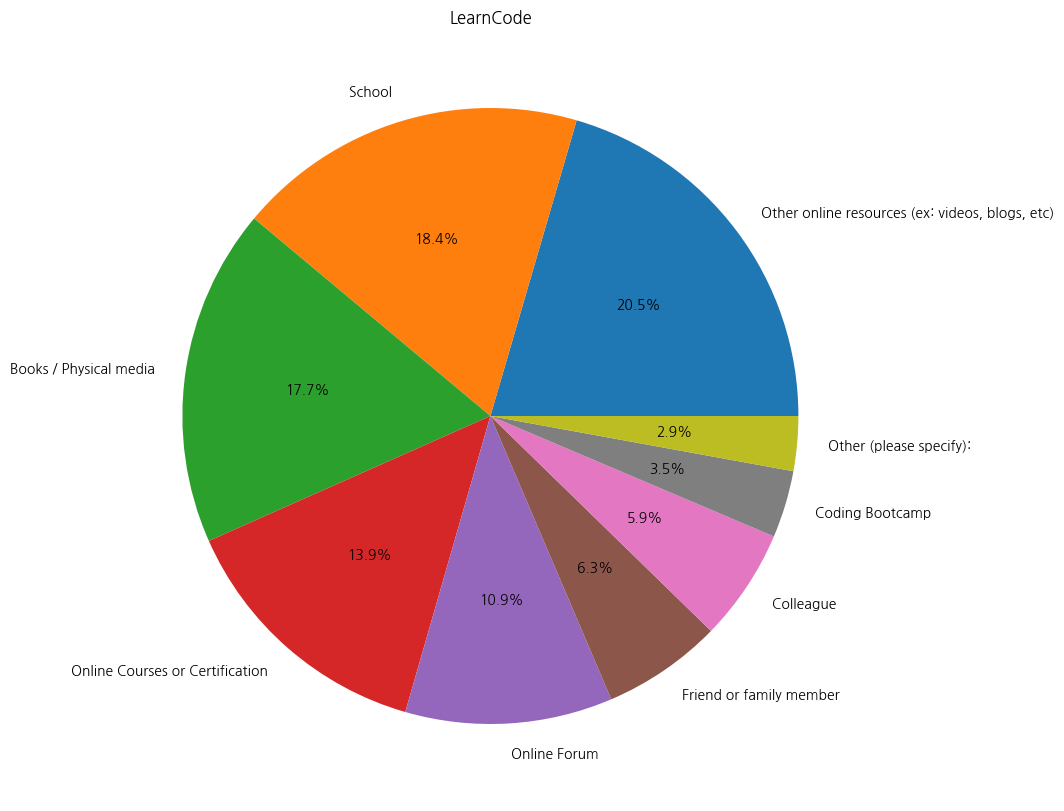

In [329]:
# 직접 풀어보기 1
# 설문조사에 응답한 개발자들이 어떻게 프로그래밍을 학습했는지 알고 싶다.
# r_data 내부에서 'LearnCode'를 추출해서 백분율을 띈 원 그래프를 생성하라.

learn_code = r_data['LearnCode'].str.split(';').explode().reset_index(drop=True).to_frame(name='LearnCode')

learn_code.groupby('LearnCode').size().nlargest(10).plot.pie(
    figsize=(10,10), autopct='%1.1f%%')

plt.title('LearnCode')

In [330]:
# 직접풀어보기 2
# 위에서 작성한 파이 스래프 연령대가 25-34세인 응답자 대상으로 그리기

e_learn_25_34 = r_data[r_data.Age=='25-34 years old']['LearnCode'].str.split(';').explode()
e_learn_25_34

,LearnCode
0,Coding Bootcamp
0,"Other online resources (ex: videos, blogs, etc)"
4,Friend or family member
8,Coding Bootcamp
9,School
...,...
83434,School
83434,Online Forum
83436,School
83437,Online Courses or Certification


In [331]:
e_learn_25_34 = e_learn_25_34.groupby(e_learn_25_34).size().nlargest(10)
e_learn_25_34

,LearnCode
LearnCode,
"Other online resources (ex: videos, blogs, etc)",19803
School,18478
Books / Physical media,15818
Online Courses or Certification,13915
Online Forum,10838
Colleague,6727
Friend or family member,5470
Coding Bootcamp,3553
Other (please specify):,2272


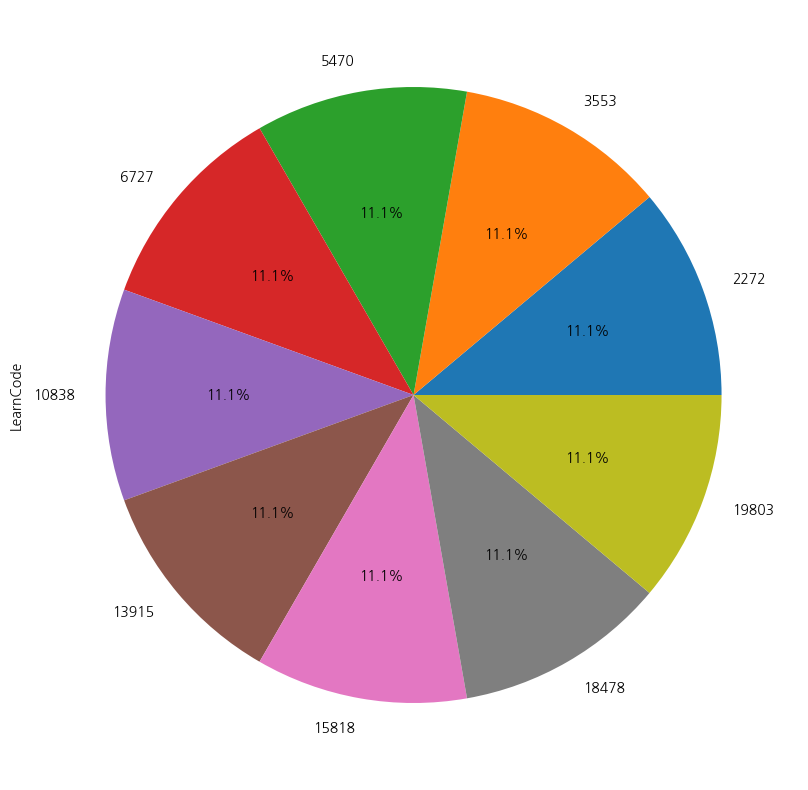

In [332]:
e_learn_25_34=e_learn_25_34.groupby(e_learn_25_34).size().nlargest(10).plot.pie(figsize=(10,10),autopct='%1.1f%%')

# 2. 한국 복지 패널 데이터

- gender : 성별(남,여)
- birth : 생일(태어난년도)
- marriage : 결혼 유무
  0. 비해당(18세미만)
  1. 유배우
  2. 사별
  3. 이혼
  4. 별거
  5. 미혼(18세이상, 미혼모 포함)
  6. 기타(사망등)
- religion : 종교 유무(1-있음. 2-없음)
- code-job : 직업코드
- income : 소득(월 평균 임금)
- code_religion : 7개 권역별 지역 구분
  1. 서울
  2. 수도권(이천/경기)
  3. 부산/경남/울산
  4. 대구/경북
  5. 대전/충남
  6. 강원/충북,
  7. 광주/전남/전북/제주도

In [333]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [334]:
import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [335]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/welfare_python.csv')
data.head()

,gender,birth,marriage,religion,code_job,income,code_religion
0,2,1936,2,2,NaN,NaN,1
1,2,1945,2,2,NaN,NaN,1
2,1,1948,2,2,942.0,120.0,1
3,1,1942,3,1,762.0,200.0,1
4,2,1923,2,1,NaN,NaN,1


In [336]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16664 entries, 0 to 16663
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gender         16664 non-null  int64  
 1   birth          16664 non-null  int64  
 2   marriage       16664 non-null  int64  
 3   religion       16664 non-null  int64  
 4   code_job       7529 non-null   float64
 5   income         4634 non-null   float64
 6   code_religion  16664 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 911.4 KB


In [337]:
data.columns

Index(['gender', 'birth', 'marriage', 'religion', 'code_job', 'income',
       'code_religion'],
      dtype='object')

In [338]:
data.loc[data['gender'] == 1,['gender']] = '남성'
data.loc[data['gender'] == 2,['gender']] = '여성'
data

/tmp/ipython-input-2913936226.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '남성' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data['gender'] == 1,['gender']] = '남성'


,gender,birth,marriage,religion,code_job,income,code_religion
0,여성,1936,2,2,NaN,NaN,1
1,여성,1945,2,2,NaN,NaN,1
2,남성,1948,2,2,942.0,120.0,1
3,남성,1942,3,1,762.0,200.0,1
4,여성,1923,2,1,NaN,NaN,1
...,...,...,...,...,...,...,...
16659,여성,1967,1,1,NaN,NaN,5
16660,여성,1992,5,1,314.0,302.5,5
16661,남성,1995,5,1,NaN,NaN,5
16662,여성,1998,0,1,NaN,NaN,5


In [339]:
year = 2020
data['age'] = year - data['birth']+1
data['age']

,age
0,85
1,76
2,73
3,79
4,98
...,...
16659,54
16660,29
16661,26
16662,23


In [340]:
def Marriage	(x):
  if x==1:
    return '결혼'
  elif x==3:
    return '이혼'
  else:
    return '무응답'
data['marriage'] = data['marriage'].apply(Marriage)
data['marriage']

,marriage
0,무응답
1,무응답
2,무응답
3,이혼
4,무응답
...,...
16659,결혼
16660,무응답
16661,무응답
16662,무응답


In [341]:
data['income'].isnull().sum()

np.int64(12030)

In [342]:
data.loc[data['income'].isnull(),'income'] = data['income'].mean()
data['income'].isnull().sum()

np.int64(0)

In [343]:
data['income']

,income
0,241.619016
1,241.619016
2,120.000000
3,200.000000
4,241.619016
...,...
16659,241.619016
16660,302.500000
16661,241.619016
16662,241.619016


In [344]:
def Religion	(x):
  if x==1:
    return '있음'
  else:
    return '없음'
data['religion'] = data['religion'].apply(Religion)
data['religion']

,religion
0,없음
1,없음
2,없음
3,있음
4,있음
...,...
16659,있음
16660,있음
16661,있음
16662,있음


In [345]:
data

,gender,birth,marriage,religion,code_job,income,code_religion,age
0,여성,1936,무응답,없음,NaN,241.619016,1,85
1,여성,1945,무응답,없음,NaN,241.619016,1,76
2,남성,1948,무응답,없음,942.0,120.000000,1,73
3,남성,1942,이혼,있음,762.0,200.000000,1,79
4,여성,1923,무응답,있음,NaN,241.619016,1,98
...,...,...,...,...,...,...,...,...
16659,여성,1967,결혼,있음,NaN,241.619016,5,54
16660,여성,1992,무응답,있음,314.0,302.500000,5,29
16661,남성,1995,무응답,있음,NaN,241.619016,5,26
16662,여성,1998,무응답,있음,NaN,241.619016,5,23


In [346]:
job_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/welfare_job.csv',encoding='cp949')
job_data

,code_job,job
0,111,의회의원 고위공무원 및 공공단체임원
1,112,기업고위임원
2,120,행정 및 경영지원 관리자
3,131,연구 교육 및 법률 관련 관리자
4,132,보험 및 금융 관리자
...,...,...
144,991,농립어업관련 단순 종사원
145,992,계기검침 수금 및 주차 관련 종사원
146,999,기타 서비스관련 단순 종사원
147,1011,장교


In [347]:
df = pd.merge(data,job_data,left_on='code_job',right_on='code_job')
df

,gender,birth,marriage,religion,code_job,income,code_religion,age,job
0,남성,1948,무응답,없음,942.0,120.000000,1,73,경비원 및 검표원
1,남성,1942,이혼,있음,762.0,200.000000,1,79,전기공
2,남성,1962,결혼,있음,530.0,241.619016,1,59,방문 노점 및 통신 판매 관련 종사자
3,남성,1962,무응답,없음,999.0,40.000000,1,59,기타 서비스관련 단순 종사원
4,남성,1978,결혼,없음,312.0,350.000000,1,43,경영관련 사무원
...,...,...,...,...,...,...,...,...,...
7524,여성,1934,결혼,없음,611.0,241.619016,6,87,작물재배 종사자
7525,남성,1956,결혼,없음,743.0,187.660000,6,65,용접원
7526,여성,1958,결혼,있음,611.0,241.619016,6,63,작물재배 종사자
7527,남성,1967,결혼,있음,874.0,241.619016,5,54,물품이동 장비 조작원


In [348]:
df['code_religion'].unique()

array([1, 7, 2, 5, 6, 3, 4])

청년 - 30세 미만  
중년 - 30세 이상  
노년 - 60세 이상  

In [349]:
def Age(x):
  if x<30:
    return '청년'
  elif x>=30:
    return '중년'
  else:
    return '노년'
df['age2'] = df['age'].apply(Age)
df['age2']

,age2
0,중년
1,중년
2,중년
3,중년
4,중년
...,...
7524,중년
7525,중년
7526,중년
7527,중년


In [350]:
df

,gender,birth,marriage,religion,code_job,income,code_religion,age,job,age2
0,남성,1948,무응답,없음,942.0,120.000000,1,73,경비원 및 검표원,중년
1,남성,1942,이혼,있음,762.0,200.000000,1,79,전기공,중년
2,남성,1962,결혼,있음,530.0,241.619016,1,59,방문 노점 및 통신 판매 관련 종사자,중년
3,남성,1962,무응답,없음,999.0,40.000000,1,59,기타 서비스관련 단순 종사원,중년
4,남성,1978,결혼,없음,312.0,350.000000,1,43,경영관련 사무원,중년
...,...,...,...,...,...,...,...,...,...,...
7524,여성,1934,결혼,없음,611.0,241.619016,6,87,작물재배 종사자,중년
7525,남성,1956,결혼,없음,743.0,187.660000,6,65,용접원,중년
7526,여성,1958,결혼,있음,611.0,241.619016,6,63,작물재배 종사자,중년
7527,남성,1967,결혼,있음,874.0,241.619016,5,54,물품이동 장비 조작원,중년


In [351]:
col = {'gender':'성별','birth':'생일','marriage':'결혼 유무','religion':'종교 유무',
       'code_job':'작업 코드','income':'소득','code_religion':'지역구','age':'나이',
       'job':'직업','ageg':'연령대'}

In [352]:
df = df.rename(columns=col)
df

,성별,생일,결혼 유무,종교 유무,작업 코드,소득,지역구,나이,직업,age2
0,남성,1948,무응답,없음,942.0,120.000000,1,73,경비원 및 검표원,중년
1,남성,1942,이혼,있음,762.0,200.000000,1,79,전기공,중년
2,남성,1962,결혼,있음,530.0,241.619016,1,59,방문 노점 및 통신 판매 관련 종사자,중년
3,남성,1962,무응답,없음,999.0,40.000000,1,59,기타 서비스관련 단순 종사원,중년
4,남성,1978,결혼,없음,312.0,350.000000,1,43,경영관련 사무원,중년
...,...,...,...,...,...,...,...,...,...,...
7524,여성,1934,결혼,없음,611.0,241.619016,6,87,작물재배 종사자,중년
7525,남성,1956,결혼,없음,743.0,187.660000,6,65,용접원,중년
7526,여성,1958,결혼,있음,611.0,241.619016,6,63,작물재배 종사자,중년
7527,남성,1967,결혼,있음,874.0,241.619016,5,54,물품이동 장비 조작원,중년


In [353]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/data/welfarClean.csv')

In [354]:
import seaborn as sns
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/welfarClean.csv')
data

,Unnamed: 0,성별,생일,결혼 유무,종교 유무,작업 코드,소득,지역구,나이,직업,age2
0,0,남성,1948,무응답,없음,942.0,120.000000,1,73,경비원 및 검표원,중년
1,1,남성,1942,이혼,있음,762.0,200.000000,1,79,전기공,중년
2,2,남성,1962,결혼,있음,530.0,241.619016,1,59,방문 노점 및 통신 판매 관련 종사자,중년
3,3,남성,1962,무응답,없음,999.0,40.000000,1,59,기타 서비스관련 단순 종사원,중년
4,4,남성,1978,결혼,없음,312.0,350.000000,1,43,경영관련 사무원,중년
...,...,...,...,...,...,...,...,...,...,...,...
7524,7524,여성,1934,결혼,없음,611.0,241.619016,6,87,작물재배 종사자,중년
7525,7525,남성,1956,결혼,없음,743.0,187.660000,6,65,용접원,중년
7526,7526,여성,1958,결혼,있음,611.0,241.619016,6,63,작물재배 종사자,중년
7527,7527,남성,1967,결혼,있음,874.0,241.619016,5,54,물품이동 장비 조작원,중년


In [355]:
r = data.groupby('결혼 유무')['결혼 유무'].count()
r

,결혼 유무
결혼 유무,
결혼,5307
무응답,1803
이혼,419


<Axes: title={'center': '결혼 유무 빈도'}, xlabel='결혼 유무', ylabel='count'>

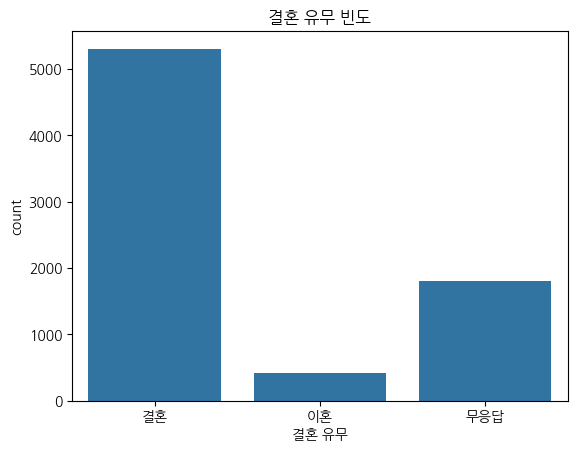

In [356]:
ord = ['결혼','이혼','무응답']
plt.figure()
plt.title('결혼 유무 빈도')
sns.countplot(x='결혼 유무',data=data,order=ord)

In [357]:
r = data.groupby(['결혼 유무','종교 유무'])['결혼 유무'].count()
r

결혼 유무  종교 유무
결혼     없음       2778
       있음       2529
무응답    없음        932
       있음        871
이혼     없음        247
       있음        172
Name: 결혼 유무, dtype: int64

<Axes: title={'center': '종교에 따른 결혼 유무 빈도'}, xlabel='결혼 유무', ylabel='count'>

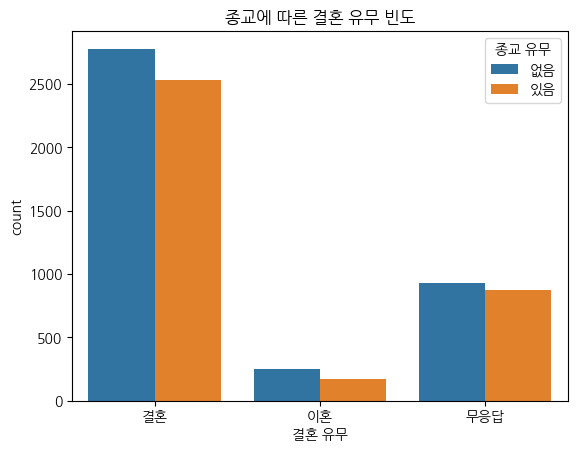

In [358]:
ord = ['결혼','이혼','무응답']
plt.figure()
plt.title('종교에 따른 결혼 유무 빈도')
sns.countplot(x='결혼 유무',hue='종교 유무',data=data,order=ord)

<Axes: title={'center': '종교에 따른 결혼 유무 빈도'}, xlabel='count', ylabel='결혼 유무'>

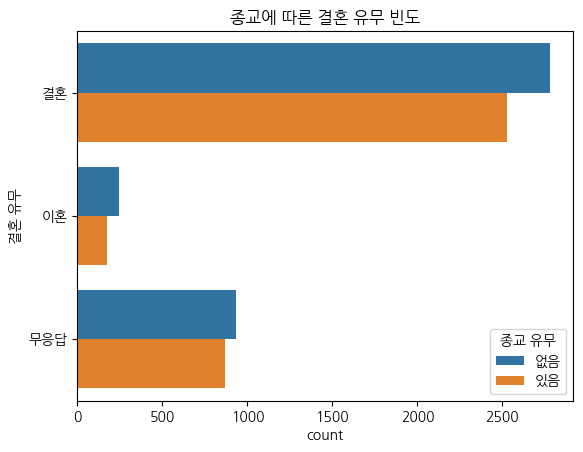

In [359]:
ord = ['결혼','이혼','무응답']
plt.figure()
plt.title('종교에 따른 결혼 유무 빈도')
sns.countplot(y='결혼 유무',hue='종교 유무',data=data,order=ord)

<Axes: title={'center': '종교에 따른 결혼 유무 빈도'}, xlabel='결혼 유무', ylabel='count'>

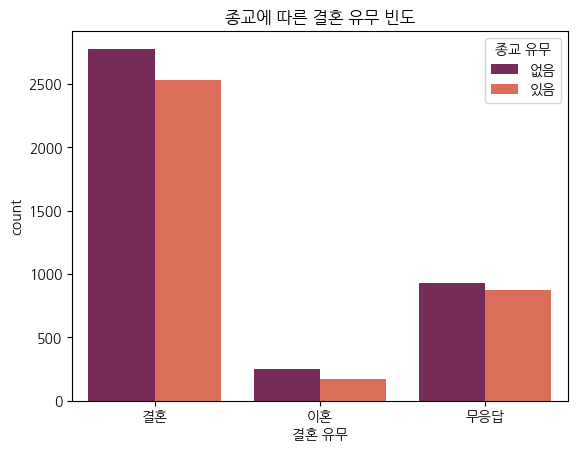

In [360]:
plt.figure()
plt.title('종교에 따른 결혼 유무 빈도')
sns.countplot(x='결혼 유무',hue='종교 유무',data=data,order=ord,palette="rocket")

/tmp/ipython-input-49300896.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x,rug=True,hist=False,kde=True)


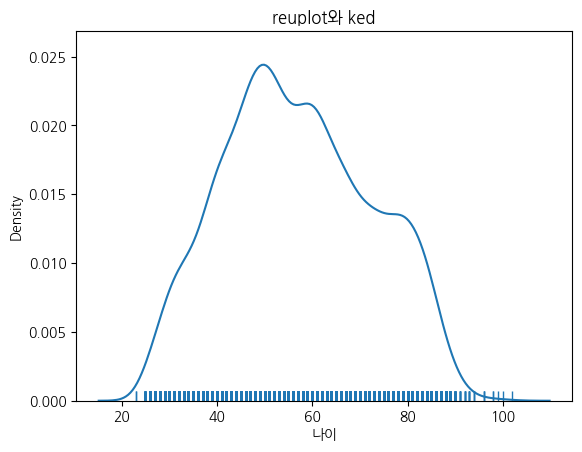

In [361]:
# kde : 커널밀도추청 = 연속적인 확률밀도 함수 곡선을 추정
# rug : 데이터의 실제 관측값들을 x축 위에 작은 선분(막대기)로 표기

x = data['나이']
plt.figure()
plt.title('reuplot와 ked')
sns.distplot(x,rug=True,hist=False,kde=True)
plt.show()

/tmp/ipython-input-4018626626.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x,rug=True,hist=True,kde=True)


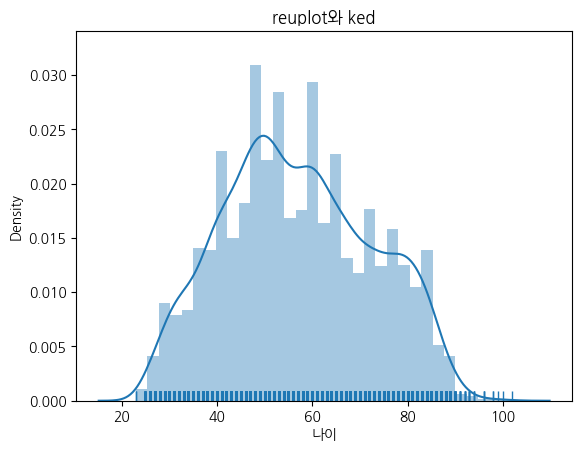

In [362]:
# kde : 커널밀도추청 = 연속적인 확률밀도 함수 곡선을 추정
# rug : 데이터의 실제 관측값들을 x축 위에 작은 선분(막대기)로 표기

x = data['나이']
plt.figure()
plt.title('reuplot와 ked')
sns.distplot(x,rug=True,hist=True,kde=True)
plt.show()

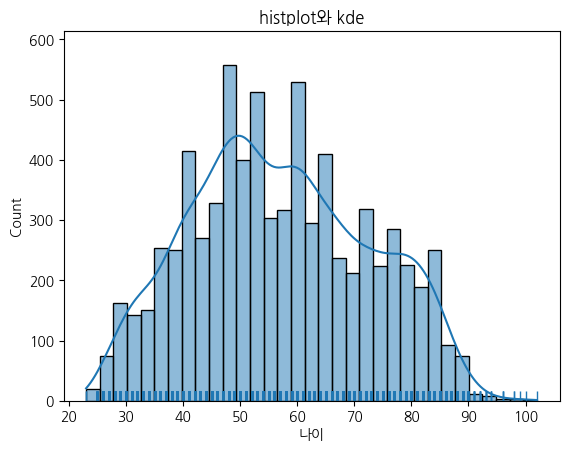

In [365]:
import matplotlib.pyplot as plt

x = data['나이']
plt.figure()
plt.title('histplot와 kde')
sns.histplot(x, kde=True)
sns.rugplot(x)
plt.show()


In [370]:
import csv

file  = open('/content/drive/MyDrive/Colab Notebooks/data/subwayfee.csv',encoding='cp949')
data = csv.reader(file)
next(data)
data

In [371]:
for row in data:
  print(row)

['2019-01', '1호선', '0150', '서울역', '1516452', '1400464', '221180', '211764']
['2019-01', '1호선', '0151', '시청', '676932', '676266', '102388', '101033']
['2019-01', '1호선', '0152', '종각', '1240810', '1177643', '162410', '152062']
['2019-01', '1호선', '0153', '종로3가', '703110', '674148', '387062', '362735']
['2019-01', '1호선', '0154', '종로5가', '571824', '583955', '275447', '263687']
['2019-01', '1호선', '0155', '동대문', '308301', '342898', '134071', '138633']
['2019-01', '1호선', '0156', '신설동', '360561', '353834', '126466', '120147']
['2019-01', '1호선', '0157', '제기동', '293540', '288217', '374571', '400607']
['2019-01', '1호선', '0158', '청량리(서울시립대입구)', '463456', '482960', '352121', '357571']
['2019-01', '1호선', '0159', '동묘앞', '174683', '188711', '146034', '147551']
['2019-01', '2호선', '0201', '시청', '706097', '679503', '61058', '55387']
['2019-01', '2호선', '0202', '을지로입구', '1415414', '1414980', '120425', '111592']
['2019-01', '2호선', '0203', '을지로3가', '608979', '601323', '91668', '91016']
['2019-01', '2호선', '0204

In [380]:
# 유임 승차와 무임승차의 비율은 어떻게 될까?
# 비율 계산 : 유임승차 / 무임승차

import csv

file  = open('/content/drive/MyDrive/Colab Notebooks/data/subwayfee.csv',encoding='cp949')
data = csv.reader(file)
next(data)

max = 0
rate = 0
m = 0

for row in data:
  for i in range(4,8):
    row[i] = int(row[i])

  if row[6] != 0:
    rate = row[4]/row[6]
    if rate > max:
      max = rate
      m = row[3]

print(m,max)

충무로 27.5


In [383]:
# 유임.무임승차의 max인 역 탐색

import csv

file  = open('/content/drive/MyDrive/Colab Notebooks/data/subwayfee.csv',encoding='cp949')
data = csv.reader(file)
next(data)

max = [0] * 4
ms = [''] * 4
label = ['유임승차','유임하차','무임승차','무임하차']

for row in data:
  for i in range(4,8):
    row[i] = int(row[i])
    if row[i] > max[i-4]:
      max[i-4] = row[i]
      ms[i-4] = row[3]

for i in range(4):
  print(label[i],':',ms[i],max[i])

유임승차 : 강남 3153418
유임하차 : 강남 3210437
무임승차 : 종로3가 387062
무임하차 : 제기동 400607
